# Survey creation using SurveyAccessor
O. Kaufmann, 2024-2025.

In [1]:
from geometron.survey import SurveyAccessor, create_survey, TopoPoint, TopoLine 
from geometron.geometries import transforms as ggt
from geometron.plot import plot_basemap
import matplotlib.pyplot as plt
import geopandas as gpd 
from shapely.geometry import Point, LineString
import shapely

## Create some landmarks in a local coordinate system
Coordinates are planar coordinates 

### Using wkt

In [2]:
L001 = TopoPoint('POINT (0. 0.)', id='L001', kind='landmark')
L002 = TopoPoint('POINT (50. 0.)', id='L002', kind='landmark')

### Using shapely geometries

In [3]:
L003 = TopoPoint(Point(4., 120.), id='L003', kind='landmark')
L004 = TopoPoint(Point(54., 112.), id='L004', kind='landmark')

### Plot L001 in a matplotlib axes

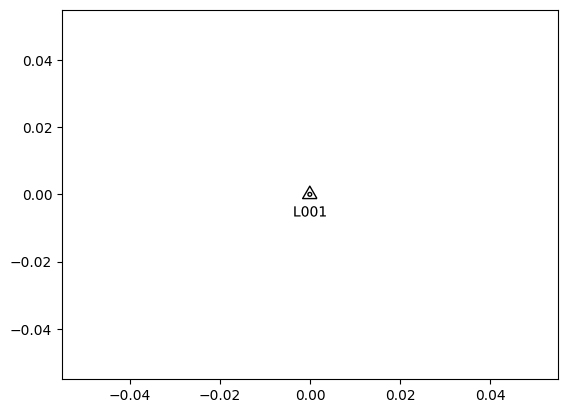

In [4]:
L001.plot()

## Add the landmarks in a new survey geodataframe and display the survey

In [5]:
gdf, f_list = create_survey([L001, L002, L003, L004])
gdf

[{'type': 'Feature', 'properties': {'id': 'L001', 'class': 'TopoPoint', 'kind': 'landmark', 'label': 'L001', 'show_label': True}, 'geometry': {'type': 'Point', 'coordinates': (0.0, 0.0)}}, {'type': 'Feature', 'properties': {'id': 'L002', 'class': 'TopoPoint', 'kind': 'landmark', 'label': 'L002', 'show_label': True}, 'geometry': {'type': 'Point', 'coordinates': (50.0, 0.0)}}, {'type': 'Feature', 'properties': {'id': 'L003', 'class': 'TopoPoint', 'kind': 'landmark', 'label': 'L003', 'show_label': True}, 'geometry': {'type': 'Point', 'coordinates': (4.0, 120.0)}}, {'type': 'Feature', 'properties': {'id': 'L004', 'class': 'TopoPoint', 'kind': 'landmark', 'label': 'L004', 'show_label': True}, 'geometry': {'type': 'Point', 'coordinates': (54.0, 112.0)}}]


,geometry,class,kind,label,show_label
id,,,,,
L001,POINT (0 0),TopoPoint,landmark,L001,True
L002,POINT (50 0),TopoPoint,landmark,L002,True
L003,POINT (4 120),TopoPoint,landmark,L003,True
L004,POINT (54 112),TopoPoint,landmark,L004,True


<Axes: >

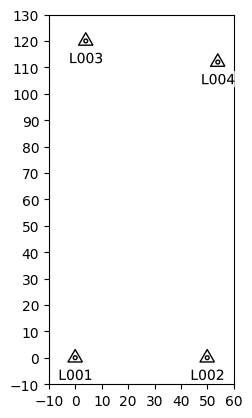

In [6]:
gdf.survey.plot()

## Create a baseline in local coordinates

### Baseline B01 joins L001 and L002

In [7]:
B01 = TopoLine(LineString([L001.geometry, L002.geometry]), id='B01', kind='baseline', show_label=False)

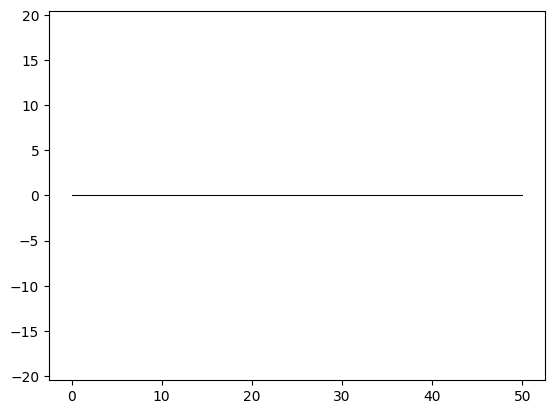

In [8]:
B01.plot()

### Baseline B02 joins L003 and L004

In [9]:
B02 = TopoLine(LineString([L003.geometry, L004.geometry]), id='B02', kind='baseline', show_label=False)

### Append the survey geodataframe

In [10]:
gdf = gdf.survey.add_features([B01, B02])

### Display the appended survey

<Axes: >

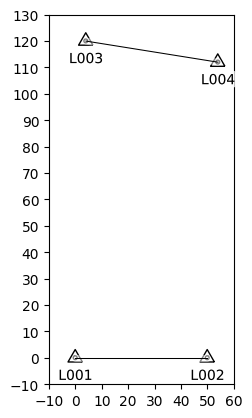

In [11]:
gdf.survey.plot()

## Add 18 meandering profiles starting and ending on the baselines
The distance between the starting and ending points along the baseline is set to 2 meters

In [12]:
number_of_profiles = 18
spacing_on_B01 = 2
spacing_on_B02 = 2

### Create the stakes where the profiles start and end

In [13]:
stakes_B01 = [TopoPoint(Point(B01.geometry.interpolate(i*spacing_on_B01)), id='', kind='stake') for i in range(1, number_of_profiles+1)]
stakes_B02 = [TopoPoint(Point(B02.geometry.interpolate(i*spacing_on_B02)), id='', kind='stake') for i in range(1, number_of_profiles+1)]

### Append the survey geodataframe and plot it

In [14]:
gdf = gdf.survey.add_features(stakes_B01)
gdf = gdf.survey.add_features(stakes_B02)

<Axes: >

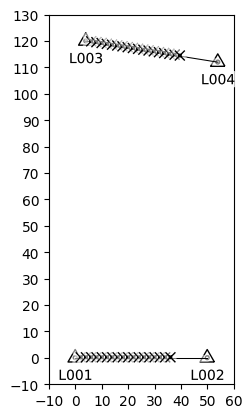

In [15]:
gdf.survey.plot()

### Create the profiles and append the survey geodataframe

In [16]:
profiles = []
for i in range(1,number_of_profiles+1,2):
    profiles.append(TopoLine(LineString([stakes_B01[i-1].geometry, stakes_B02[i-1].geometry]), id=f'P{i:02d}', kind='profile'))
for i in range(2,number_of_profiles+1,2):
    profiles.append(TopoLine(LineString([stakes_B02[i-1].geometry, stakes_B01[i-1].geometry]), id=f'P{i:02d}', kind='profile'))

In [17]:
gdf = gdf.survey.add_features(profiles)

<Axes: >

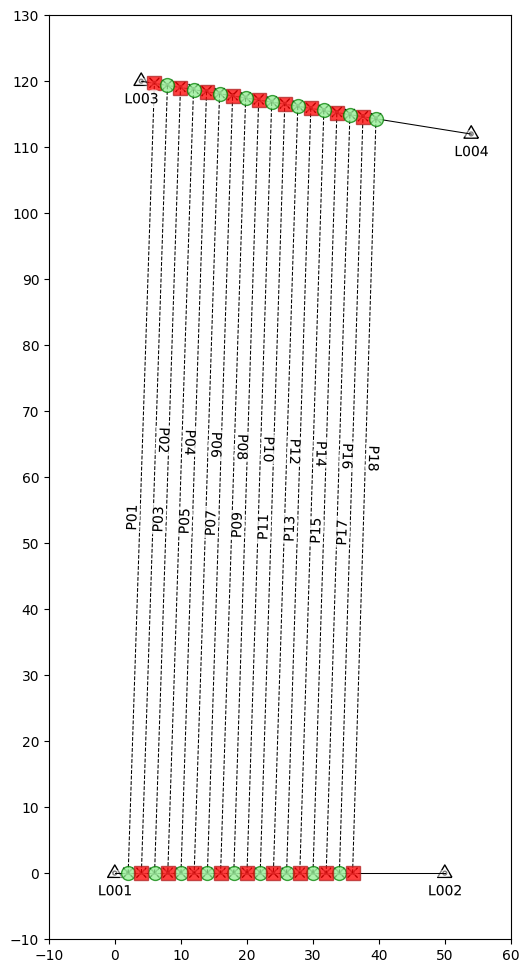

In [18]:
fig, ax = plt.subplots(figsize=(6,12))
gdf.survey.plot(ax=ax)

## Transform from local coordinates to geographic coordinates
Here an affine transform is used. Based on the use case other approaches could be better suited.

### Define the control points for the affine transform

In [19]:
origin_coords = [L001, L002, L003, L004]

In [20]:
landmarks = gpd.read_file('./data/landmarks.shp')
landmarks.set_index('Label', drop=False, inplace=True)
landmarks.crs

<Projected CRS: EPSG:3812>
Name: ETRS89 / Belgian Lambert 2008
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Belgium - onshore.
- bounds: (2.5, 49.5, 6.4, 51.51)
Coordinate Operation:
- name: Belgian Lambert 2008
- method: Lambert Conic Conformal (2SP)
Datum: European Terrestrial Reference System 1989 ensemble
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [21]:
destination_coords = [(i.x, i.y) for i in landmarks.loc[['L001', 'L002', 'L003', 'L004'], 'geometry'].values]

### Compute the transform matrix

In [22]:
matrix, residual, _, _  = ggt.affine_transform_matrix(origin_coords=origin_coords, destination_coords=destination_coords)

In [23]:
residual

array([1.70078765, 5.30641372])

### Save the local coordinates in wkt format in the 'local_geometry' column and apply the transform to the survey geodataframe

In [24]:
gdf['local_geometry'] = gdf['geometry'].to_wkt()

In [25]:
gdf['geometry'] = gpd.GeoSeries.from_wkt(gdf['local_geometry']).affine_transform(matrix)
gdf.crs = landmarks.crs

## Plot the transformed survey on a basemap
NOTE:  
The survey geodataframe should be converted to WGS84 (epsg:4326) for display over a basemap created with geometron.plot.plot_basemap.  
It should be located entirely within the extent of the basemap

### Compute the extent of the map using a buffer around the survey geodataframe

In [26]:
extent = gdf.buffer(10).to_crs('epsg:4326').total_bounds[[0,2,1,3]]

In [27]:
cache_dir = './tmp_files/.tiles_cache'

### Plot the basemap and the survey geodataframe

<Axes: >

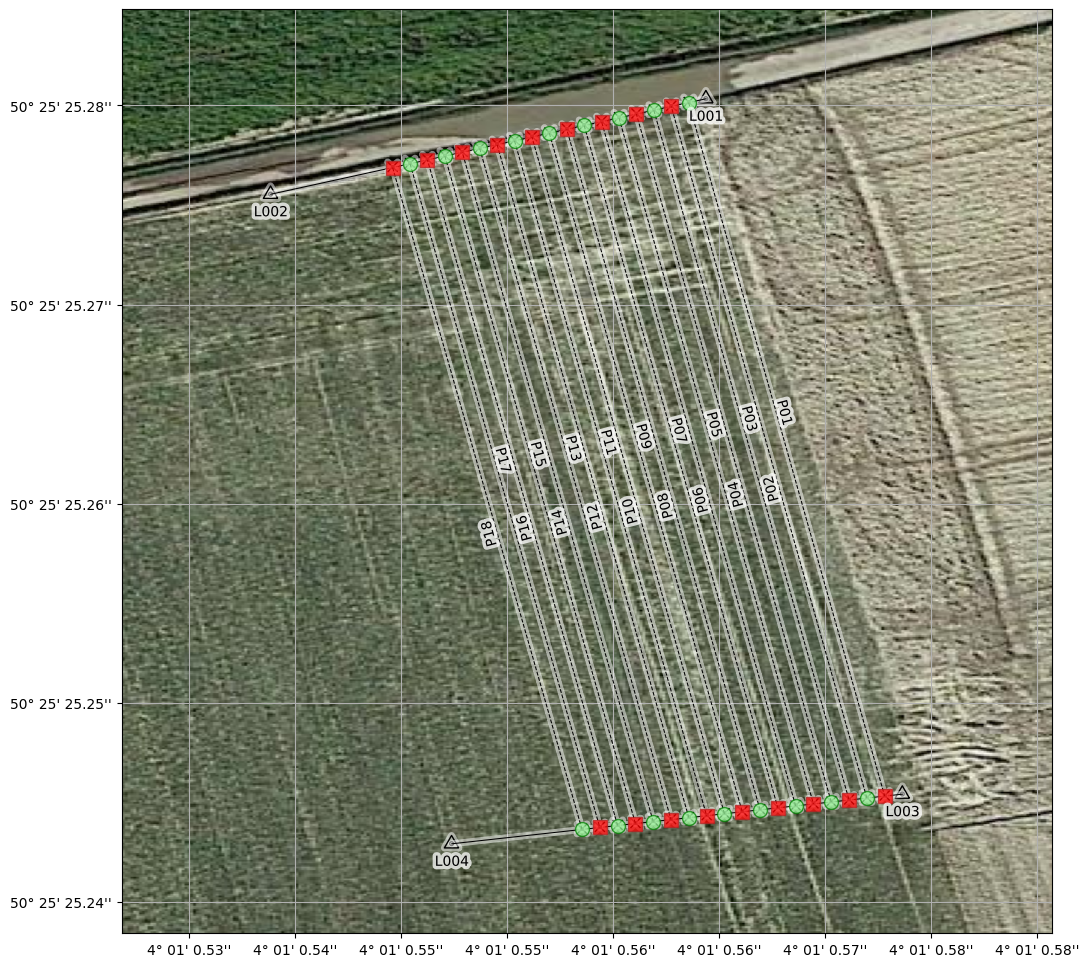

In [28]:
ax = plot_basemap(extent, figsize=(12,12), xyz_server='google terrain', cache_dir=cache_dir, max_zoom=19)
gdf.to_crs('epsg:4326').survey.plot(ax=ax, grid='on')

## Export the survey geodataframe to a geopackage

In [29]:
gdf.to_file('./tmp_files/survey.gpkg', driver='GPKG')